# Fig 5.6

0.032 0.028800000000000003 20
I,t 182 19.99719074698606
I,t 304.4045914466416 20.0
I,t 192.2267713497131 20.0
I,t 0.6571341500384733 20.0
0.032 0.032 20
I,t 914 19.99969579867195
I,t 1531.360556985197 20.0
I,t 981.723650011867 20.0
I,t 2.1594773721153615 20.0
0.032 0.048 20
I,t 19116 19.999990610213644
I,t 20340.97814081555 20.0
I,t 19276.18489557319 20.0
I,t 648.686951233205 20.0
0.032 0.0352 20
I,t 3914 19.999918106303582
I,t 4907.207994725195 20.0
I,t 3541.7470462182027 20.0
I,t 7.033546643287991 20.0


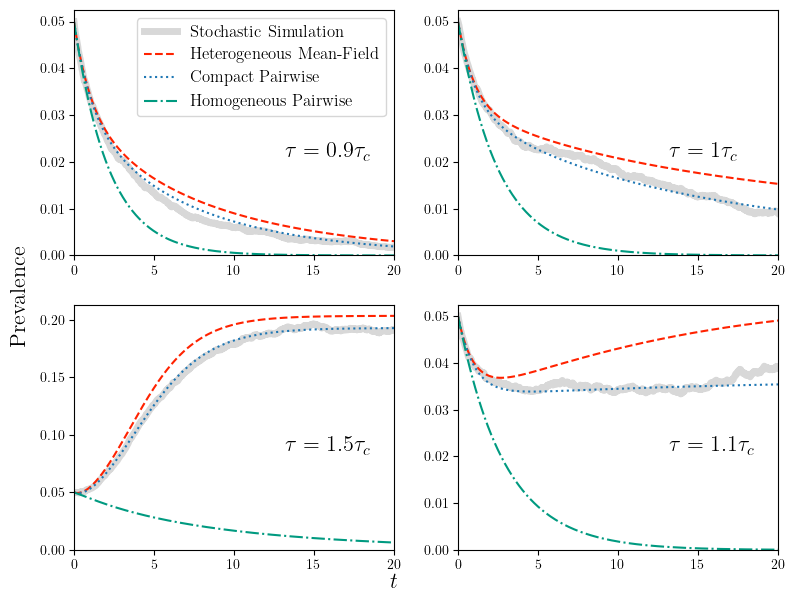

In [1]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'



N=100000  
iterations = 1
rho = 0.05
tmax = 20
tcount = 1001
kave = 20.
ksqave = (5**2 + 35**2)/2.

gamma = 1
tau_c = gamma*kave/ksqave

ksmall = 5
kbig = 35
deg_dist = [ksmall, kbig]*int(N/2)

report_times = np.linspace(0, tmax, tcount)

fig, axes = plt.subplots(2,2,figsize=(8,6))
axes=axes.flatten()
plt.subplots_adjust(left=0.1, right=0.98, top=0.98, bottom=0.08)
for tau_factor, label, ax in zip([0.9, 1, 1.5, 1.1],['a', 'b', 'c', 'd'], axes):
    tau = tau_factor*tau_c
    Isum = np.zeros(len(report_times))

    print(str(tau_c)+" "+str(tau) + " " + str(tmax))

    
    G = nx.configuration_model(deg_dist)
    t, S, I = EoN.fast_SIS(G, tau, gamma, tmax=tmax, rho=rho)
    I = EoN.subsample(report_times, t, I)
    ax.plot(report_times, I/N, label = 'Stochastic Simulation', color='grey', linewidth=5, alpha=0.3)
    print('I,t', I[-1], t[-1])
    degree_array = np.zeros(kbig+1)
    degree_array[kbig]=N/2
    degree_array[ksmall]=N/2
    Sk0 = degree_array*(1-rho)
    Ik0 = degree_array*rho

    t, S, I = EoN.SIS_heterogeneous_meanfield(Sk0, Ik0, tau, gamma, tmax=tmax,
                                                tcount=tcount)
    ax.plot(t, I/N, '--', label = 'Heterogeneous Mean-Field', color = colorI)
    print('I,t', I[-1], t[-1])

    SI0 = ((kbig + ksmall)*N/2.)*(1-rho)*rho
    SS0 = ((kbig+ksmall)*N/2.)*(1-rho)*(1-rho)
    II0 = ((kbig+ksmall)*N/2.)*rho*rho

    t, S, I = EoN.SIS_compact_pairwise(Sk0, Ik0, SI0, SS0, II0, tau, gamma, 
                                tmax=tmax, tcount=tcount)
    ax.plot(t, I/N, ':', label = 'Compact Pairwise')
    #t, S, I = EoN.SIS_compact_pairwise(Sk0, I0, SI0, SS0, II0, tau, gamma, tmax=tmax, tcount=tcount)
    #plt.plot(t, I/N)
    print('I,t', I[-1], t[-1])

    I0 = N*rho
    S0 = N*(1-rho)
    kave = (kbig+ksmall)/2.

    t, S, I = EoN.SIS_homogeneous_pairwise(S0, I0, SI0, SS0, kave, tau, gamma, tmax=tmax, tcount=tcount)
    ax.plot(t, I/N, '-.', label = 'Homogeneous Pairwise', color = colorS)
    print('I,t', I[-1], t[-1])

    ax.set_xlim(xmin=0, xmax=20)
    ax.set_ylim(ymin=0)
    
    ax.text(0.66, 0.4, '$\\tau = {}\\tau_c$'.format(tau_factor), transform=ax.transAxes, fontsize=16)

axes[0].legend(fontsize=12)
fig.supylabel('Prevalence', fontsize=16)
fig.supxlabel('$t$', fontsize=16)
plt.savefig('fig5p6.png', dpi=900)

# Figure 5.7

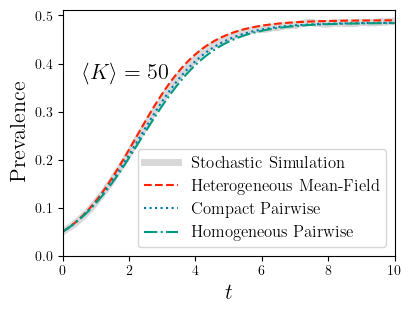

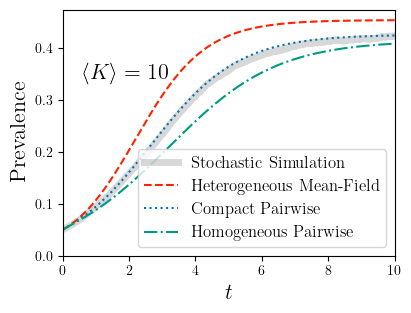

In [2]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'


def sim_and_plot(G, tau, gamma, rho, tmax, tcount, ax):
    t, S, I = EoN.fast_SIS(G, tau, gamma, rho=rho, tmax = tmax)
    report_times = np.linspace(0, tmax, tcount)
    I = EoN.subsample(report_times, t, I)
    ax.plot(report_times, I/N, label = 'Stochastic Simulation', color='grey', linewidth=5, alpha=0.3)

    t, S, I, = EoN.SIS_heterogeneous_meanfield_from_graph(G, tau, gamma, rho=rho,
                                                    tmax=tmax, tcount=tcount)
    ax.plot(t, I/N, '--', label = 'Heterogeneous Mean-Field', color = colorI)
    t, S, I = EoN.SIS_compact_pairwise_from_graph(G, tau, gamma, rho=rho,
                                                    tmax=tmax, tcount=tcount)
    ax.plot(t, I/N, ':', label = 'Compact Pairwise', color=colorI2)

    t, S, I = EoN.SIS_homogeneous_pairwise_from_graph(G, tau, gamma, rho=rho,
                                                    tmax=tmax, tcount=tcount)
    ax.plot(t, I/N, '-.', label = 'Homogeneous Pairwise', color=colorS)


tcount = 1001
tmax = 10.
gamma = 1.
N=100000
rho = 0.05

#fig = plt.figure(1)
#main = plt.axes()
plt.figure(0, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.16)
plt.figure(1, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.16)

for target_kave, fig_id in zip((50, 10), [0, 1]):
    fig=plt.figure(fig_id)
    ax = plt.gca()

    G = nx.fast_gnp_random_graph(N, target_kave/(N-1.))
    kave = sum(G.degree(node) for node in G.nodes())/N
    ksqave =sum(G.degree(node)**2 for node in G.nodes())/N
    tau_c = gamma*kave/ksqave
    tau = 2*tau_c

    sim_and_plot(G, tau, gamma, rho, tmax, tcount, ax)

    plt.xlabel('$t$', fontsize=16)
    plt.ylabel('Prevalence', fontsize=16)
    plt.text(0.2, 0.75, '$\\langle K \\rangle = {}$'.format(target_kave), transform=fig.transFigure, fontsize=16)
    
# target_kave = 10.

# G = nx.fast_gnp_random_graph(N, target_kave/(N-1.))
# kave = sum(G.degree(node) for node in G.nodes())
# ksqave =sum(G.degree(node)**2 for node in G.nodes())
# tau_c = gamma*kave/ksqave
# tau = 2*tau_c

# sim_and_plot(G, tau, gamma, rho, tmax, tcount, inset)

plt.figure(0)
plt.xlim(xmin=0, xmax=10)
plt.ylim(ymin=0)
plt.legend(fontsize=12)
plt.savefig('fig5p7a.png', dpi=900)
plt.figure(1)
plt.xlim(xmin=0, xmax=10)
plt.ylim(ymin=0)
plt.legend(fontsize=12)
plt.savefig('fig5p7b.png', dpi=900)

# Fig 5.8

2.64784
24.7466
0.10699813307686712
4.211358846548225
28.04976
1430.30762
0.019610998087250628
25.36766808247065


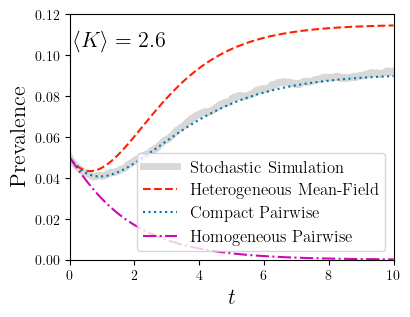

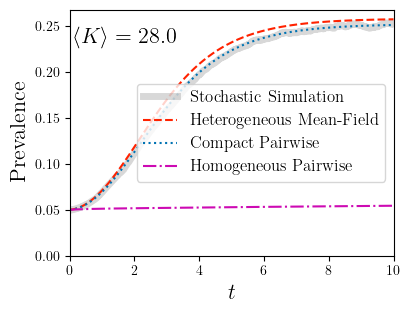

In [3]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'


def get_deg_seq(N, Pk):
    while True:  #run until degree sequence has even sum of N entries
        deg_seq = []
        for counter in range(N):
            r = random.random()
            for k in Pk:
                if Pk[k]>r:
                    break
                else:
                    r-= Pk[k]
            deg_seq.append(k)
        if sum(deg_seq)%2 ==0:
            break
    return deg_seq



def sim_and_plot(G, tau, gamma, rho, tmax, tcount, ax):
    t, S, I = EoN.fast_SIS(G, tau, gamma, rho = rho, tmax = tmax)
    report_times = np.linspace(0, tmax, tcount)
    I = EoN.subsample(report_times, t, I)
    ax.plot(report_times, I/N, color='grey', linewidth=5, alpha=0.3, label = 'Stochastic Simulation')

    t, S, I, = EoN.SIS_heterogeneous_meanfield_from_graph(G, tau, gamma, rho=rho,
                                                    tmax=tmax, tcount=tcount)
    ax.plot(t, I/N, '--', label = 'Heterogeneous Mean-Field', color=colorI)
    t, S, I = EoN.SIS_compact_pairwise_from_graph(G, tau, gamma, rho=rho,
                                                    tmax=tmax, tcount=tcount)
    ax.plot(t, I/N, ':', label = 'Compact Pairwise', color = colorI2)

    t, S, I = EoN.SIS_homogeneous_pairwise_from_graph(G, tau, gamma, rho=rho,
                                                    tmax=tmax, tcount=tcount)
    ax.plot(t, I/N, '-.', label = 'Homogeneous Pairwise', color=colorR)

N=100000
gamma = 1
rho = 0.05
tmax = 10
tcount = 1001

plt.figure(0, figsize= (4,3))
plt.subplots_adjust(left=0.17, right=0.98, top=0.98, bottom=0.16)
plt.figure(1, figsize= (4,3))
plt.subplots_adjust(left=0.17, right=0.98, top=0.98, bottom=0.16)

for (kmin, kmax), fig_id in zip(((1,40), (10, 150)), [0, 1]):
    fig=plt.figure(fig_id)
    ax = plt.gca()
# kmin = 1
# kmax = 40
    Pk = {}
    for k in range(kmin, kmax+1):
        Pk[k] = k**(-2.)
    norm_factor = sum(Pk.values())
    for k in Pk:
        Pk[k] /= norm_factor

    deg_seq = get_deg_seq(N, Pk)
    G = nx.configuration_model(deg_seq)
    kave = sum(G.degree(node) for node in G.nodes())/N
    ksqave =sum(G.degree(node)**2 for node in G.nodes())/N
    #    kave = sum(deg_seq)/N

    tau = 2*gamma*kave/ksqave

    print(kave) 
    print(ksqave)
    print(gamma*kave/ksqave)
    print((ksqave - kave**2)**0.5)
# fig = plt.figure(1)
# main = plt.axes()
    sim_and_plot(G, tau, gamma, rho, tmax, tcount, ax)


# kmin = 10
# kmax = 150
# Pk = {}
# for k in range(kmin, kmax+1):
#     Pk[k] = k**(-2.)
# norm_factor = sum(Pk.values())
# for k in Pk:
#     Pk[k] /= norm_factor


# deg_seq = get_deg_seq(N, Pk)
# G = nx.configuration_model(deg_seq)
# kave = (sum(deg_seq)/N)

# tau = 1.5*gamma/kave

# fig = plt.figure(1)
# ax1 = plt.gca()
# inset = plt.axes([0.45,0.175,0.45,0.45])
# sim_and_plot(G, tau, gamma, rho, tmax, tcount, inset)
    plt.xlabel('$t$', fontsize=16)
    plt.ylabel('Prevalence', fontsize=16)
    plt.text(0.18, 0.87, '$\\langle K \\rangle = {:.1f}$'.format(kave), transform=fig.transFigure, fontsize=16)
    #plt.yticks([0, 0.1, 0.2, 0.3])
plt.figure(0)

plt.xlim(xmin=0, xmax=10)
plt.ylim(ymin=0)
plt.legend(fontsize=12)
plt.savefig('fig5p8a.png', dpi=900)
plt.figure(1)

plt.xlim(xmin=0, xmax=10)
plt.ylim(ymin=0)
plt.legend(fontsize=12)
plt.savefig('fig5p8b.png', dpi=900)

# Fig 5.9

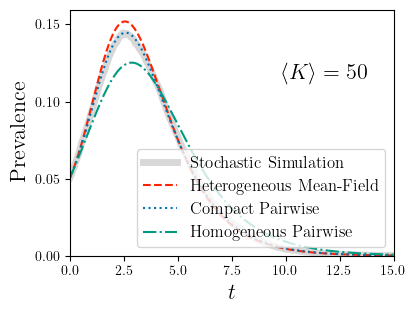

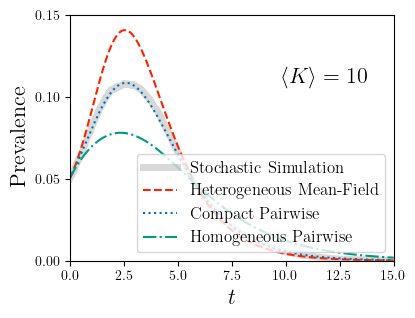

In [4]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'


def sim_and_plot(G, tau, gamma, rho, tmax, tcount, ax):
    t, S, I, R= EoN.fast_SIR(G, tau, gamma, rho = rho, tmax = tmax)
    report_times = np.linspace(0, tmax, tcount)
    I = EoN.subsample(report_times, t, I)
    ax.plot(report_times, I/N, color='grey', linewidth=5, alpha=0.3, label='Stochastic Simulation')

    t, S, I, R = EoN.SIR_heterogeneous_meanfield_from_graph(G, tau, gamma, rho=rho,
                                                    tmax=tmax, tcount=tcount)
    ax.plot(t, I/N, '--', label = 'Heterogeneous Mean-Field', color = colorI)
    t, S, I, R = EoN.SIR_compact_pairwise_from_graph(G, tau, gamma, rho=rho,
                                                    tmax=tmax, tcount=tcount)
    ax.plot(t, I/N, ':', label = 'Compact Pairwise', color = colorI2)

    t, S, I, R = EoN.SIR_homogeneous_pairwise_from_graph(G, tau, gamma, rho=rho,
                                                    tmax=tmax, tcount=tcount)
    ax.plot(t, I/N, '-.', label = 'Homogeneous Pairwise', color = colorS)

N=100000
gamma = 1
rho = 0.05
tmax = 15
tcount = 1001


plt.figure(0, figsize= (4,3))
plt.subplots_adjust(left=0.17, right=0.98, top=0.98, bottom=0.16)
plt.figure(1, figsize= (4,3))
plt.subplots_adjust(left=0.17, right=0.98, top=0.98, bottom=0.16)

for (kmin, kmax), fig_id in zip(((30,70), (5, 15)), [0, 1]):
    fig=plt.figure(fig_id)
    ax = plt.gca()

    deg_seq = [kmin]*int(N/2) + [kmax]*int(N/2)
    G = nx.configuration_model(deg_seq)
    kave = sum(deg_seq)/N
    ksqave = sum(k*k for k in deg_seq)/N

    tau= 2*gamma*kave/ksqave

# fig = plt.figure(1)
# main = plt.axes()
    sim_and_plot(G, tau, gamma, rho, tmax, tcount, ax)
    plt.ylabel('Prevalence', fontsize=16)
    plt.xlabel('$t$', fontsize=16)
    plt.text(0.7, 0.75, '$\\langle K \\rangle = {}$'.format(int(kave+0.01)), transform=fig.transFigure, fontsize=16)
    plt.yticks([0, 0.05, 0.1, 0.15])

# deg_seq = [5]*int(N/2) + [15]*int(N/2)
# G = nx.configuration_model(deg_seq)

# kave = (sum(deg_seq)/N)
# ksqave = sum(k*k for k in deg_seq)/N

# tau= 2*gamma*kave/ksqave

# fig = plt.figure(1)
# ax1 = plt.gca()
# inset = plt.axes([0.5,0.45,0.4,0.4])
# sim_and_plot(G, tau, gamma, rho, tmax, tcount, inset)

# ax1.set_xlabel('$t$')
# ax1.set_ylabel('Prevalence')
plt.figure(0)
plt.xlim(xmin=0, xmax=tmax)
plt.ylim(ymin=0)
plt.legend(loc = 'lower right', fontsize=12)
plt.savefig('fig5p9a.png', dpi=900)
plt.figure(1)
plt.xlim(xmin=0, xmax= tmax)
plt.ylim(ymin=0)
plt.legend(loc = 'lower right', fontsize=12)
plt.savefig('fig5p9b.png', dpi=900)